In [2]:
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import dataclass


In [3]:


from typing import Iterable, Sized


@dataclass
class SimulationParameters:
    executors: int
    round_trip_time : float 
    database_size: int
    passwords_size: int
    mean_password_chars: int 
    mean_hash_time: float
    network_velocity: float
    disk_velocity: float
    cpu_speed: float
    hash_size : int 
    pass

@dataclass
class SimulationResult:
    total_time : float 
    comm_time : float 
    comp_time : float 
    speedup : float
    cc_ratio: float
    efficiency : float
    database_size : int 
    password_size : int 
    cost: float
    executors: int
    pass

class Simulation:
    def __init__(self, params: SimulationParameters):
        self.p = params
        pass

    def execute(self, executors, database_size)-> np.ndarray:
        results = np.empty((len(database_size),len(executors)),dtype=object)
        oldparams = self.p
        for i,ds in enumerate(database_size):
            for j,ex in enumerate(executors):
                self.p.executors = ex
                self.p.database_size = ds
                result = SimulationResult(
                    total_time=self.runtime(),
                    comm_time=self.t_comm(),
                    comp_time=self.t_comp(),
                    speedup=self.speedup(),
                    cc_ratio=self.t_comp()/self.t_comm(),
                    database_size=self.p.database_size,
                    password_size=self.p.passwords_size,
                    executors=self.p.executors,
                    efficiency=self.efficiency(),
                    cost= self.runtime() *  self.p.executors
                )
                results[i,j] = result
                pass
        self.p = oldparams
        return results
    
    def t_comm(self) -> float:
        return NotImplemented
    def t_comp(self) -> float:
        return NotImplemented
    def t_seq(self)->float:
        return NotImplemented
    def space(self)-> float:
        return NotImplemented
    

    def runtime(self)-> float :
        return self.t_comp() + self.t_comm()
    def speedup(self) -> float:
        return self.t_seq()/self.runtime()
    def efficiency(self) -> float:
        return (self.speedup() / self.p.executors)*100
    def L(self,x):
        return x/ self.p.disk_velocity
    def S(self,x):
        return x / self.p.network_velocity
    def H(self,x):
        return self.p.mean_hash_time * x
    def C(self,x,y):
        return ((x*y)*self.p.hash_size)/self.p.cpu_speed

    pass


sha256_sim_param = SimulationParameters(
    executors=1,
    round_trip_time=1*10**-5,
    database_size=1,
    passwords_size=10000,
    mean_password_chars=16,
    mean_hash_time=2.7*10**-6, # seconds
    network_velocity=2.5*10**9,  # GB/s
    disk_velocity=700*10**6,       # MB/s
    cpu_speed=1.8*10**9,            # GHz
    hash_size=32                   # bytes
)




In [4]:
class SequentialSimulation(Simulation):
    def t_seq_comm(self) -> float:
        return self.L(self.p.database_size*self.p.hash_size) + self.L(self.p.passwords_size*self.p.mean_password_chars) 

    def t_seq_comp(self) -> float:
        return self.H(self.p.passwords_size) + self.C(self.p.database_size, self.p.passwords_size)

    def t_seq(self) -> float:
        return self.t_seq_comm() + self.t_seq_comp()
    def t_comm(self) -> float:
        return self.t_seq_comm()
    def t_comp(self) -> float:
        return self.t_seq_comp()
    pass

sim = SequentialSimulation(sha256_sim_param).execute([x for x in range(1,100)],[10**i for i in range(1,10)])
print(f"Runtime {sim[8,0].comp_time}, Tcomm {sim[8,0].comm_time}")


Runtime 177777.80477777778, Tcomm 45.71451428571429


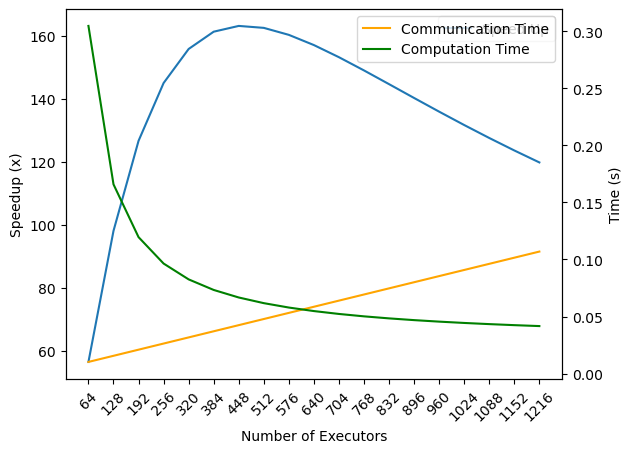

In [5]:
from matplotlib.pyplot import xlabel, ylabel

class LinearSimulation(SequentialSimulation):
    def t_comm(self) -> float:
        return self.L(self.p.passwords_size*self.p.mean_password_chars) + self.L(self.p.database_size*self.p.hash_size) + self.S(self.p.passwords_size*self.p.mean_password_chars) * self.p.executors + self.S(self.p.database_size*self.p.hash_size/self.p.executors)+ 2 * self.p.round_trip_time * self.p.executors
    def t_comp(self) -> float:
        return self.H(self.p.passwords_size) + self.C(self.p.database_size/self.p.executors, self.p.passwords_size)
    pass



scale = LinearSimulation(sha256_sim_param).execute([64*i for i in range(1,20)], [(10**5)*i for i in range(1,20)])

def plot_speedup(scale,index):
# set labels in plot
    xlabel('Number of Executors')
    ylabel('Speedup (x)')
    plt.plot([x for x in range(len(scale[index]))], [x.speedup for x in scale[index]] , label='Speed Up')
    # add to x the correct labels
    plt.xticks([x for x in range(len(scale[index]))], [f"{int(s.executors)}" for s in scale[index]], rotation=45)
    plt.legend()
    # add third axis 
    plt.twinx()
    plt.ylabel('Time (s)')
    plt.plot([x for x in range(len(scale[index]))], [s.comm_time for s in scale[index]], label='Communication Time', color='orange')
    plt.plot([x for x in range(len(scale[index]))], [s.comp_time for s in scale[index]], label='Computation Time', color='green')
    plt.legend()
    plt.show()

plot_speedup(scale,0)  # Plot for the first instance of scale

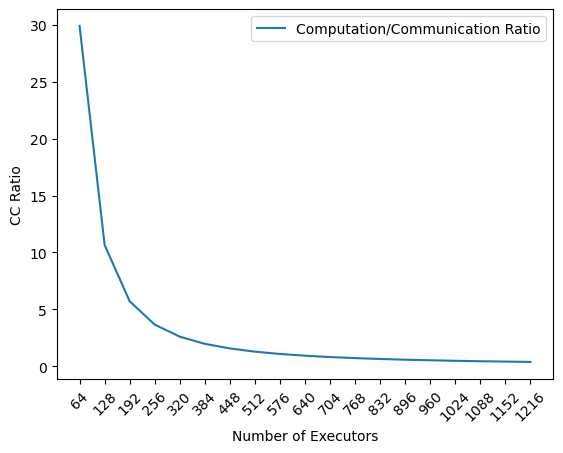

In [6]:
def plot_cc_ratio(scale,index):
    plt.plot([x for x in range(len(scale[index]))], [s.cc_ratio for s in scale[index]], label='Computation/Communication Ratio')
    plt.xticks([x for x in range(len(scale[index]))], [f"{int(s.executors)}" for s in scale[index]], rotation=45)
    plt.xlabel('Number of Executors')
    plt.ylabel('CC Ratio')
    plt.legend()
    plt.show()

plot_cc_ratio(scale,0)  # Plot for the first instance of scale

[56.54304908627314, 98.15095360973096, 126.73397226740772, 145.08413884742768, 155.8967705289859, 161.3835002124445, 163.2148337104816, 162.59595686524932, 160.37379973327654, 157.1343982401001, 153.27932813832825, 149.08176144306458, 144.72617664128572, 140.33599487287375, 135.99265367163702, 131.7487327956213, 127.63698865628194, 123.67658433596837, 119.87739702614536]


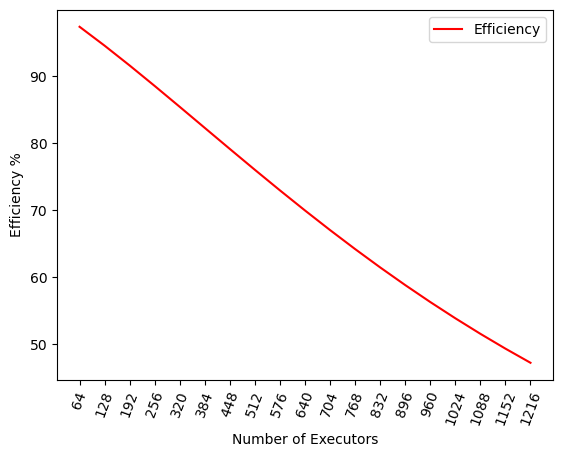

In [7]:
def plot_efficiency(scale,index):
    efficiency = [s.efficiency for s in scale[index]]
    plt.plot([x for x in range(len(efficiency))], efficiency, label='Efficiency', color='red')
    plt.xlabel('Number of Executors')
    plt.xticks([x for x in range(len(scale[index]))], [f"{int(s.executors)}" for s in scale[index]], rotation=70)
    plt.ylabel('Efficiency %')
    plt.legend()
    plt.show()

print([s.speedup for s in scale[0]])
plot_efficiency(scale,10)  # Plot for the first instance of scale

X shape: (19, 19) Y shape: (19, 19) Z shape: (19, 19)
Z min/max: 56.54304908627314 683.953563152388


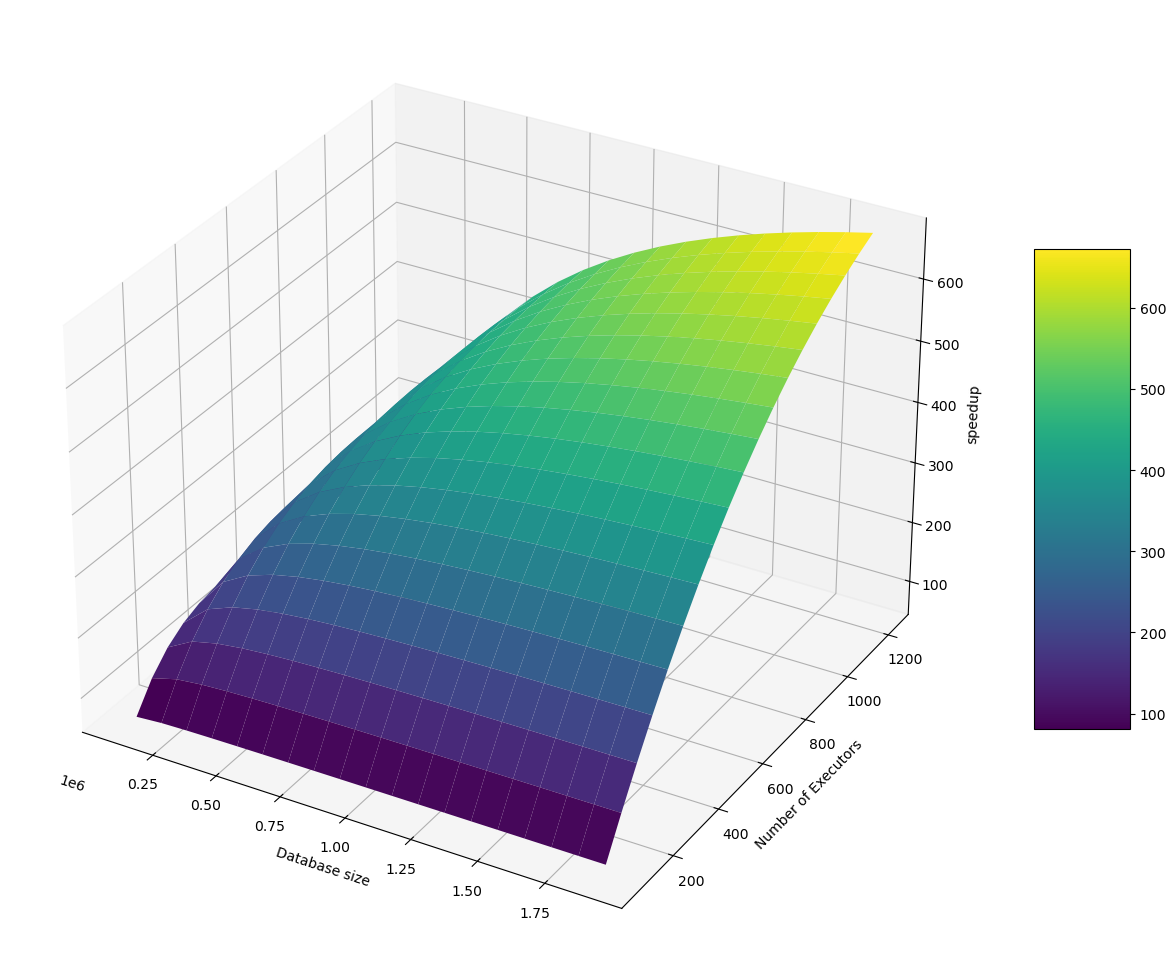

X shape: (19, 19) Y shape: (19, 19) Z shape: (19, 19)
Z min/max: 9.85833857122906 97.81275569399452


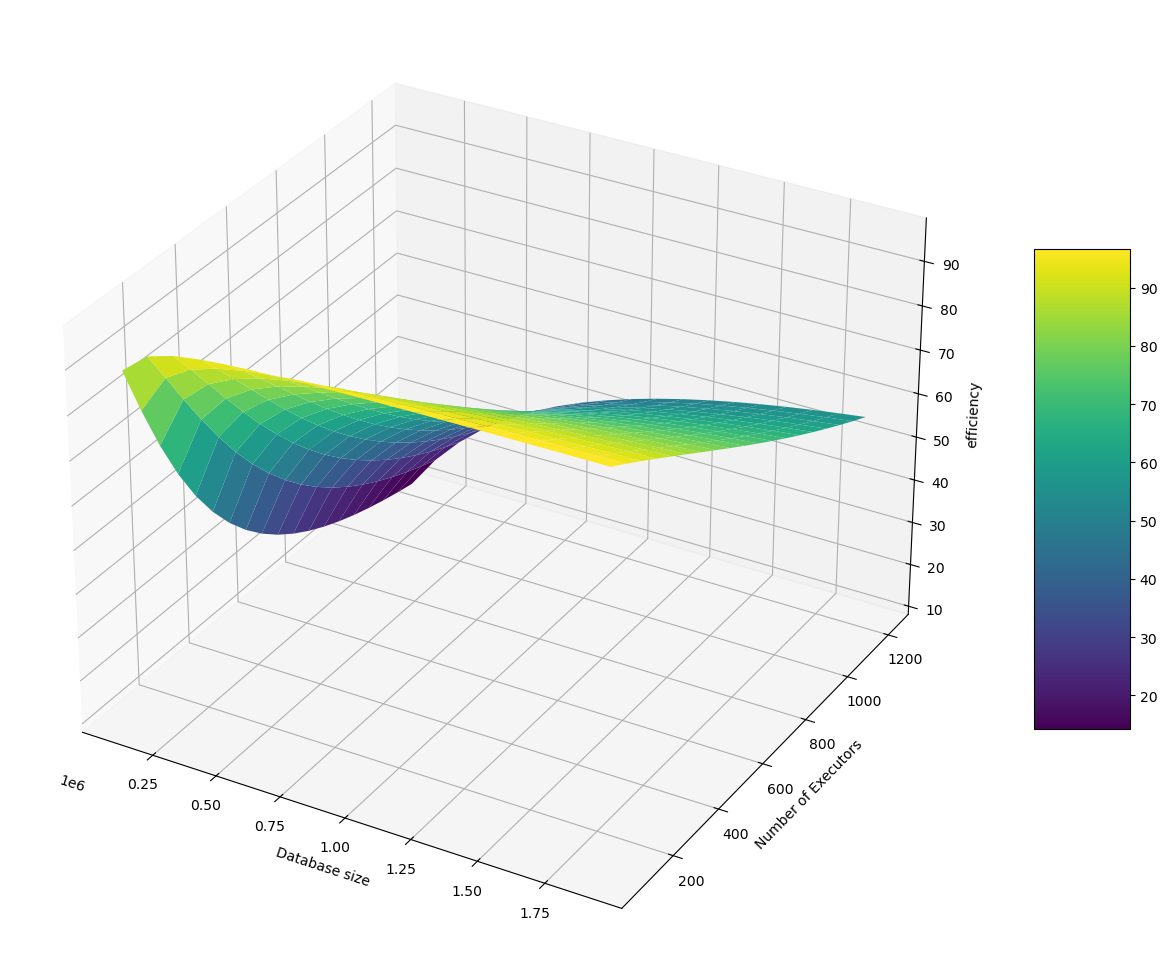

X shape: (19, 19) Y shape: (19, 19) Z shape: (19, 19)
Z min/max: 0.3891707191384941 57.13786974519527


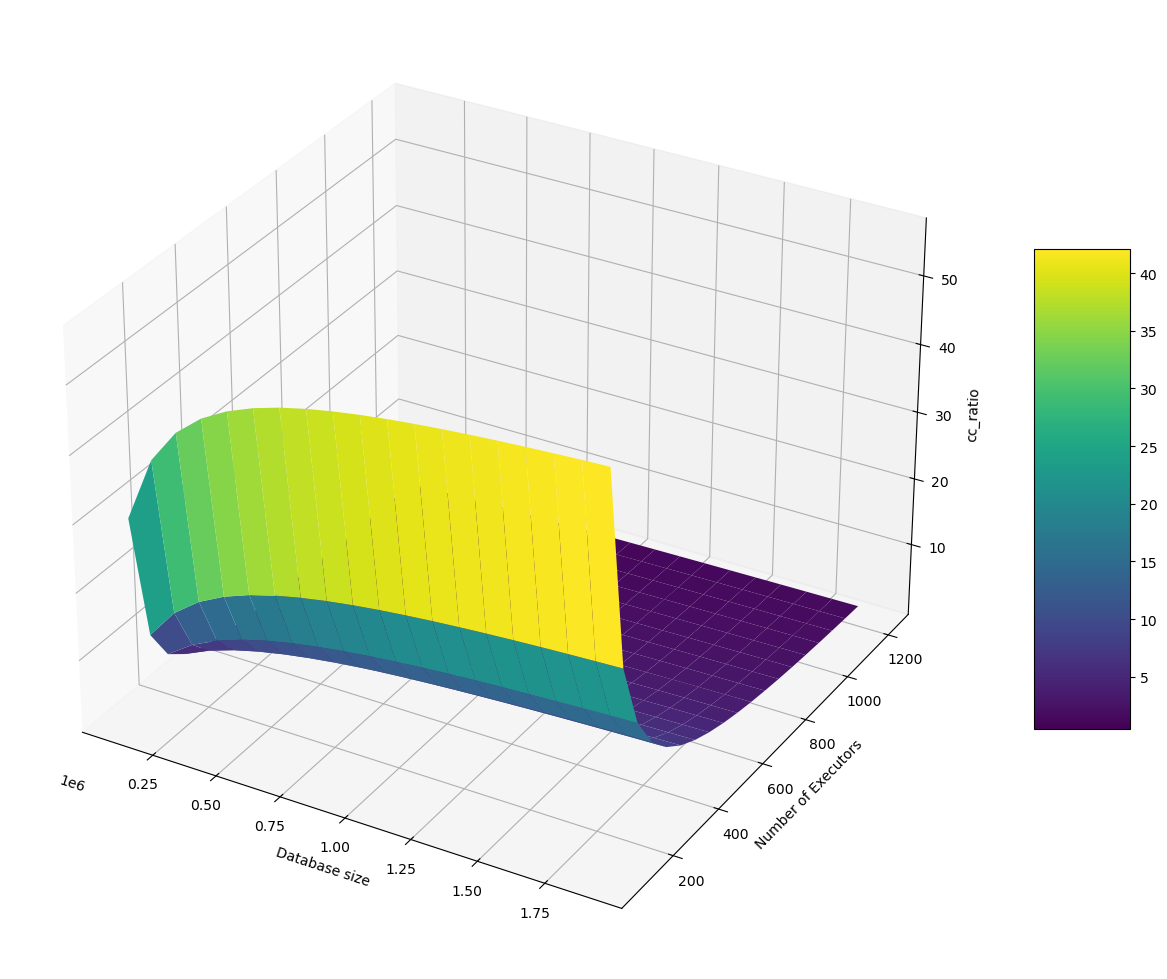

X shape: (19, 19) Y shape: (19, 19) Z shape: (19, 19)
Z min/max: 20.15832177777778 600.7374303492063


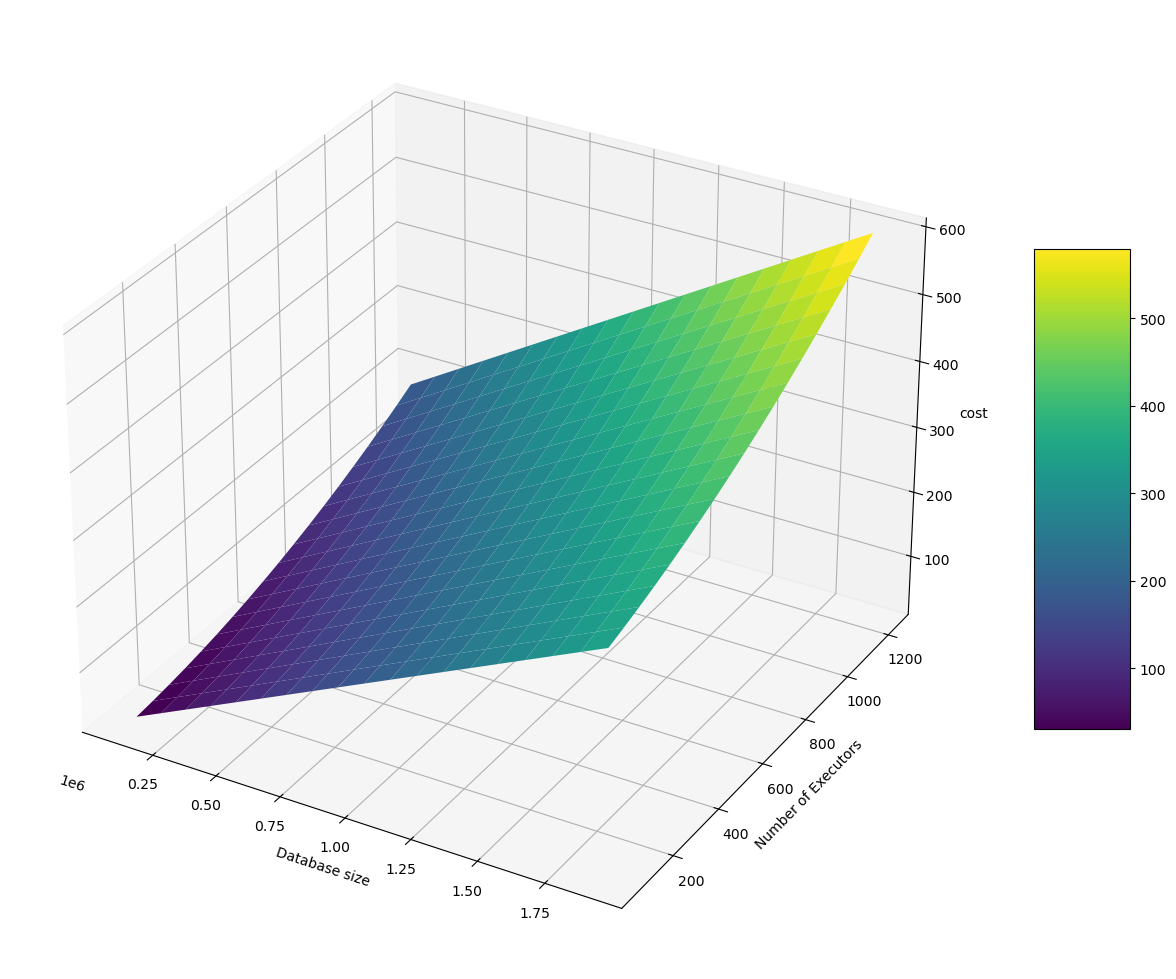

In [ ]:
import math
from numpy import meshgrid


def plot_measure(result: list[list[SimulationResult]], measure: str):

    Y_vals = [x[0].database_size for x in result]
    X_vals = [x.executors for x in result[0]]  # <-- non dividere per 10
    X, Y = np.meshgrid(X_vals, Y_vals, indexing='ji')
    Z = np.zeros((len(X_vals), len(Y_vals)))
    for i in range(len(X_vals)):
        for j in range(len(Y_vals)):
            Z[i, j] = result[i][j].__getattribute__(measure)
    print("X shape:", X.shape, "Y shape:", Y.shape, "Z shape:", Z.shape)
    print("Z min/max:", np.nanmin(Z), np.nanmax(Z))
    fig = plt.figure()
    ax = fig.add_axes((0, 0, 2, 2), projection='3d')
    surf = ax.plot_surface(X, Y, Z, cmap='viridis')
    ax.set_xlabel('Database size')
    ax.set_ylabel('Number of Executors')
    ax.set_zlabel(measure)
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
    plt.show()

    
plot_measure(scale, 'speedup')
plot_measure(scale, 'efficiency')
plot_measure(scale, 'cc_ratio')
plot_measure(scale, 'cost')

In [9]:
class RingSimulation(SequentialSimulation):

    def t_comm(self) -> float:
        return self.L(self.p.passwords_size*self.p.mean_password_chars) + self.L(self.p.database_size*self.p.hash_size) + self.S(self.p.passwords_size*self.p.mean_password_chars) + self.S(self.p.database_size*self.p.hash_size/self.p.executors)+ 2 * self.p.round_trip_time * self.p.executors + self.t_transitory()
    
    def t_comp(self) -> float:
        return self.H(self.p.passwords_size) + self.C(self.p.database_size/self.p.executors, self.p.passwords_size/self.p.executors)*self.p.executors

    def t_transitory(self)-> float:
        return self.t_task()*((self.p.executors-1)*self.p.executors)/2

    def t_task(self)->float:
        return self.C(self.p.database_size/self.p.executors, self.p.passwords_size/self.p.executors) + self.S(self.p.database_size/self.p.executors) + self.p.round_trip_time * self.p.executors
    pass

scale = RingSimulation(sha256_sim_param).execute([16*i for i in range(1,20)], [(10**5)*i for i in range(1,20)])

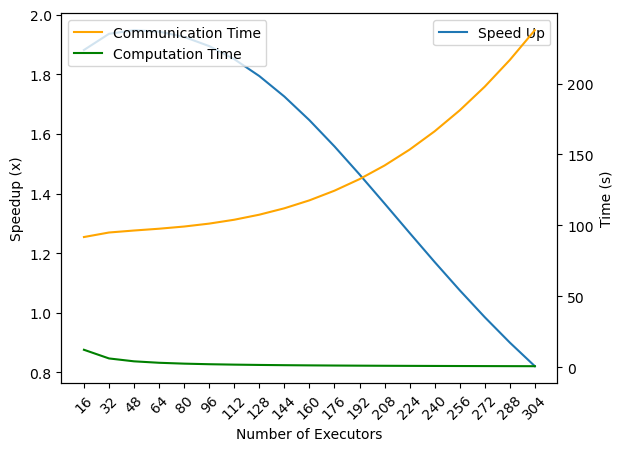

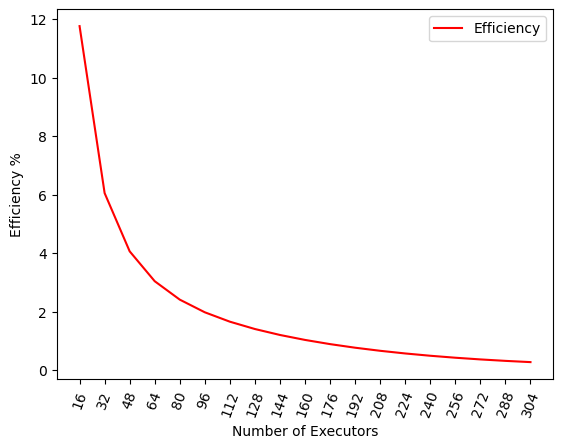

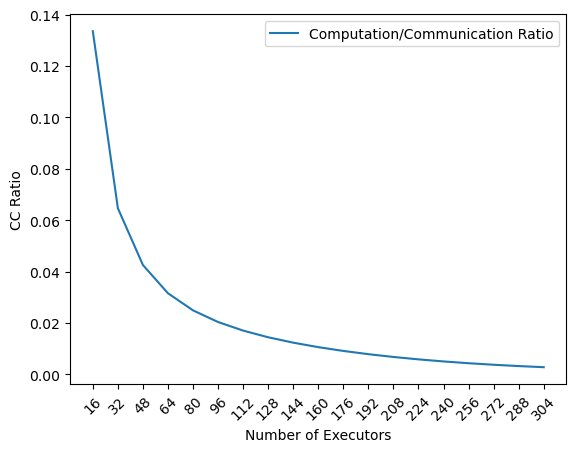

In [10]:
plot_speedup(scale,10)  # Plot for the first instance of scale
plot_efficiency(scale,10)  # Plot for the first instance of scale
plot_cc_ratio(scale,10)  # Plot for the first instance of scale

X shape: (19, 19) Y shape: (19, 19) Z shape: (19, 19)
Z min/max: 0.11954953094329387 1.9536090711136656


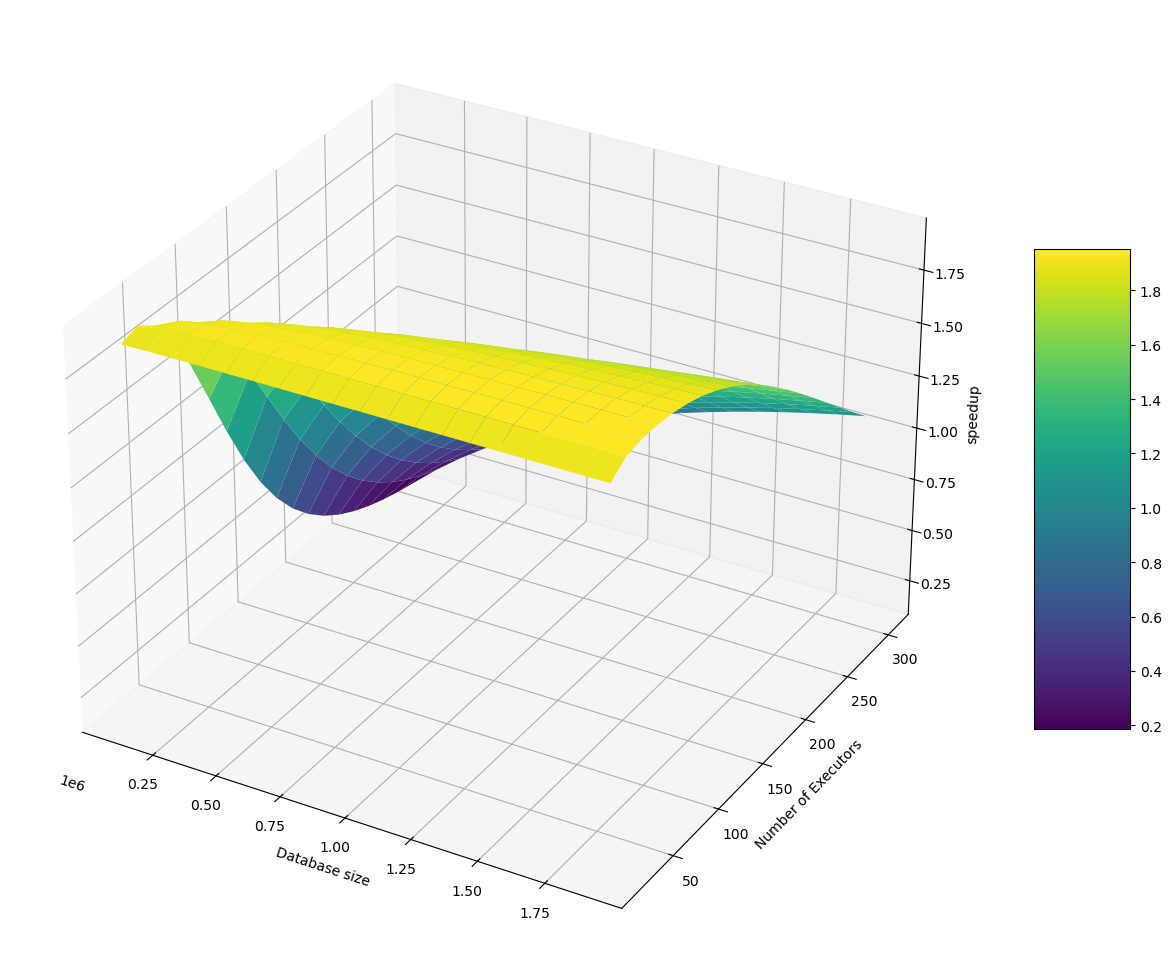

X shape: (19, 19) Y shape: (19, 19) Z shape: (19, 19)
Z min/max: 0.039325503599767726 11.75944659801016


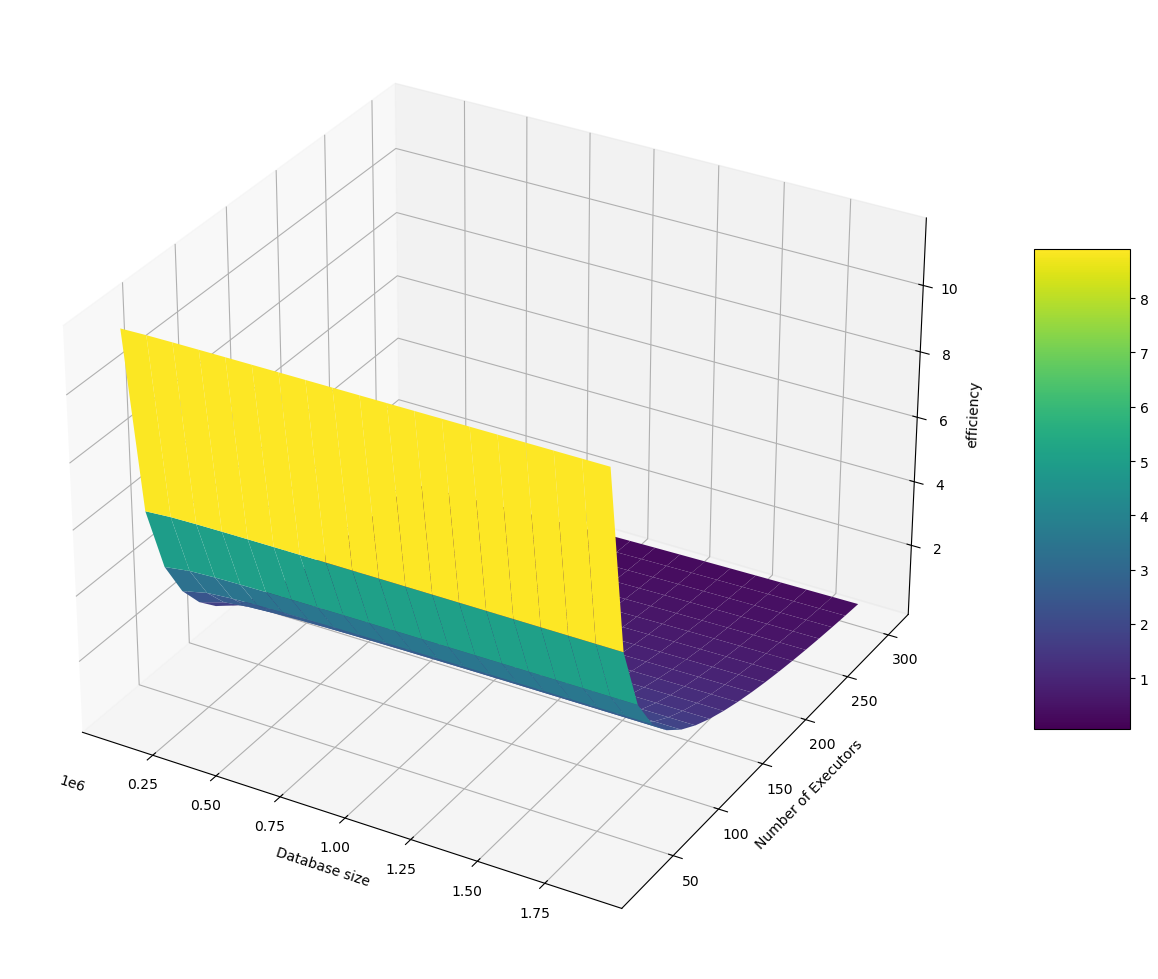

In [11]:
plot_measure(scale,"speedup")
plot_measure(scale,"efficiency")

In [12]:
class BlockRingSimulation(SequentialSimulation):
    task_size = 2000
    
    def t_comm(self) -> float:
        return self.L(self.p.passwords_size*self.p.mean_password_chars) + self.L(self.p.database_size*self.p.hash_size) + self.S(self.p.passwords_size*self.p.mean_password_chars) + self.S(self.p.database_size*self.p.hash_size/self.p.executors)+ 2 * self.p.round_trip_time * self.p.executors + self.t_transitory()
    
    def t_comp(self) -> float:
        return self.H(self.p.passwords_size) + self.C(self.p.database_size/self.p.executors, self.p.passwords_size/self.p.executors)*self.p.executors

    def t_transitory(self)-> float:
        return self.t_task()*((self.p.executors-1)*self.p.executors)/2

    def t_task(self)->float:
        return self.C(self.p.database_size/self.p.executors, self.p.passwords_size/self.p.executors) + self.S(self.p.database_size/self.p.executors) + self.p.round_trip_time * self.p.executors
    pass

$T_{seq}= L(N)+H(N)+L(K)+H(K)+C_h(K)$

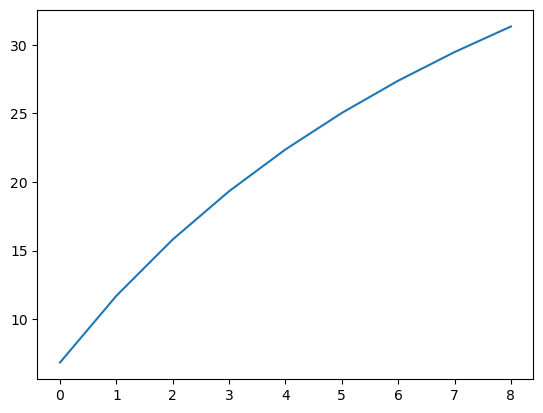

In [ ]:
class DHTSequentialSimulation(Simulation):
    def Ch(self, k: int)-> float:
        return k/self.p.cpu_speed
    def t_seq_comm(self) -> float:
        return self.L(self.p.database_size*self.p.hash_size) + self.L(self.p.passwords_size*self.p.mean_password_chars) 

    def t_seq_comp(self) -> float:
        return self.H(self.p.passwords_size) + self.Ch(self.p.passwords_size) + self.H(self.p.database_size)

    def t_seq(self) -> float:
        return self.t_seq_comm() + self.t_seq_comp()
    def t_comm(self) -> float:
        return self.t_seq_comm()
    def t_comp(self) -> float:
        return self.t_seq_comp()
    pass


res = DHTSequentialSimulation(sha256_sim_param).execute([x for x in range(1,100)],[1000*i for i in range(1,100)])
seq = SequentialSimulation(sha256_sim_param).execute([x for x in range(1,100)],[1000*i for i in range(1,100)])
plt.plot([x for x in range(9)], [seq[x,10].total_time/res[x,10].total_time for x in range(9)], label='time')

rank = world().rank
if(rank is root)
{
    map = hashmap()
    database= load_database()
    passwords = load_passwords()
    password_list = split(passwords,world().size)
    foreach hash in database{
        node = hash%world().size
        if(node == root){
            map.add(hash)
        }
        else{
            send(hash,node)
        }
    }
    send(distributionphasetermination)
    barrier()
    for pwd in password{
        pshw= hash(pwd)
        node = pshw % world().size
        if(node == root){
            if map.contains(pshw){
                notify_password(pshw,password)
            }
        }
        else{
            send(node,password)
        }
    }
    send(crackphasetermination)

}
else
{
    map = hashmap()
    hash;
    while not terminatedistphase{
        recv(hash)
        map.add(hash)
    }
    barrier()
    while not terminatecrckphase{
        recv(password)
        hash = hash(password)
        if(map.contains(hash)){
            notify_password(pshw,password)
        }
    }
}